# OUTLIER DETECTION

## What is an Outlier?

An **outlier** is an observation that is unusually different from the rest of the data.

Important:

> **Outlier ≠ Error**

An outlier can be a valid observation.

Example:

```text
Salary:
25,000
28,000
30,000
32,000
35,000
5,00,000
````

`5,00,000` is an outlier, but it may be a genuine high salary.

### Outlier Detection Workflow

```text
Detect
  ↓
Investigate
  ↓
Decide
  ↓
Keep / Remove / Correct / Transform
```

---

# 1. IQR METHOD

**IQR = Interquartile Range**

IQR measures the spread of the middle 50% of the data.

### Quartiles

* **Q1** = 25th percentile
* **Q2** = 50th percentile = Median
* **Q3** = 75th percentile

### Formula

```text
IQR = Q3 - Q1
```

### Lower Bound

```text
Lower Bound = Q1 - 1.5 × IQR
```

### Upper Bound

```text
Upper Bound = Q3 + 1.5 × IQR
```

Values below the lower bound or above the upper bound are considered **potential outliers**.

### Pandas

```python
Q1 = df["Salary"].quantile(0.25)
Q3 = df["Salary"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df["Salary"] < lower) |
    (df["Salary"] > upper)
]
```

### Count Outliers

```python
outliers.shape[0]
```

### Box Plot

```python
df["Salary"].plot(kind="box")
```

A box plot can visually show potential outliers.

### When is IQR Useful?

IQR is especially useful for:

* Skewed data
* Data containing extreme values
* Numerical variables
* Data where the mean and standard deviation may be heavily affected by outliers

---

# 2. Z-SCORE METHOD

A **Z-score** measures how many standard deviations an observation is away from the mean.

### Formula

```text
z = (x - mean) / standard deviation
```

Interpretation:

* `z = 0` → value is equal to the mean
* Positive z-score → value is above the mean
* Negative z-score → value is below the mean
* Large absolute z-score → value is far from the mean

### Common Rule

```text
|z| > 3
```

→ Potential outlier.

### Python

```python
from scipy.stats import zscore

df["z_score"] = zscore(df["Salary"])

outliers = df[
    df["z_score"].abs() > 3
]
```

### When is Z-Score Useful?

Z-score works best when the data is **approximately normally distributed**.

It is commonly used for:

* Approximately normal distributions
* Numerical data
* Univariate outlier detection

---

# 3. IQR vs Z-SCORE

| IQR                             | Z-Score                              |
| ------------------------------- | ------------------------------------ |
| Based on Q1 and Q3              | Based on mean and standard deviation |
| Less affected by extreme values | More affected by extreme values      |
| Good for skewed data            | Good for approximately normal data   |
| Uses quartiles                  | Uses mean and standard deviation     |

### Simple Rule

```text
Skewed data
    ↓
IQR
```

```text
Approximately normal data
    ↓
Z-Score
```

---

# 4. ISOLATION FOREST

**Isolation Forest** is a machine-learning method used for **anomaly detection**.

Instead of using statistical boundaries, it builds random decision trees and tries to **isolate observations**.

The basic idea:

> **Outliers are easier to isolate, so they usually require fewer splits.**

### Python

```python
from sklearn.ensemble import IsolationForest

model = IsolationForest(
    contamination=0.05,
    random_state=42
)

model.fit(df[["Salary"]])

df["outlier"] = model.predict(
    df[["Salary"]]
)
```

### Prediction

```text
 1  → Normal
-1  → Outlier
```

### Find Outliers

```python
outliers = df[
    df["outlier"] == -1
]
```

---

# Contamination

Example:

```python
contamination=0.05
```

This tells the Isolation Forest model that approximately **5% of the observations are expected to be anomalies**.

Important:

> Do not blindly choose contamination just to obtain a desired number of outliers.

The value should be based on domain knowledge or a reasonable assumption about the data.

---

# 5. When to Use Each Method

### IQR

Use IQR for:

* Univariate numerical data
* Skewed distributions
* Data with extreme values
* Situations where a robust statistical method is preferred

### Z-Score

Use Z-score for:

* Approximately normally distributed data
* Univariate numerical data
* Situations where mean and standard deviation are appropriate

### Isolation Forest

Use Isolation Forest for:

* Large datasets
* Multiple features
* Complex anomaly patterns
* Cases where simple statistical rules may not be sufficient

---

# 6. Outlier Treatment

After detecting an outlier, **do not automatically delete it**.

Follow this process:

### 1. Keep it

If the outlier is a valid observation, keep it.

Example:

```text
Salary = ₹5,00,000
```

If the salary is genuine, it should not be removed just because it is unusual.

### 2. Remove it

Remove the observation if it is clearly erroneous.

Example:

```text
Age = 250
```

if the dataset represents human ages.

### 3. Correct it

If the original correct value is known, correct the error.

Example:

```text
Age = 250
```

may actually have been entered as `25`.

### 4. Cap extreme values

Replace extreme values with a predefined upper or lower limit when appropriate.

This is sometimes called **Winsorization**.

### 5. Transform the data

For highly skewed numerical data, transformations such as a **log transformation** may reduce the effect of extreme values.

---

# Important Rules ⚠️

* An outlier is not automatically an error.
* Always investigate the reason behind an outlier.
* Do not automatically remove all detected outliers.
* IQR is generally more robust to extreme values than Z-score.
* Z-score is more appropriate for approximately normal data.
* Isolation Forest can detect more complex anomaly patterns.
* The appropriate method depends on the dataset and the problem.
* Domain knowledge is important when deciding whether an outlier should be kept or removed.

---

# 🧠 Quick Memory

```text
IQR
↓
Quartiles
↓
Good for skewed data
```

```text
Z-Score
↓
Mean + Standard Deviation
↓
Good for approximately normal data
```

```text
Isolation Forest
↓
Machine Learning
↓
Isolation / Anomaly Detection
↓
Useful for complex patterns and multiple features
```

### Final Rule

> **Detect → Investigate → Decide → Treat**

Never:

> **Detect → Delete**

```
```


In [2]:
import pandas as pd

data = {
    "Employee": [
        "A","B","C","D","E",
        "F","G","H","I","J",
        "K","L"
    ],
    "Age": [
        22, 24, 25, 26, 27, 28,
        29, 30, 31, 32, 35, 80
    ],
    "Salary": [
        25000, 28000, 30000, 32000,
        35000, 37000, 40000, 42000,
        45000, 48000, 50000, 300000
    ]
}

df = pd.DataFrame(data)

In [3]:
#IQR METHOD

Q1 = df["Salary"].quantile(0.25)
Q3 = df["Salary"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df["Salary"] < lower) |
    (df["Salary"] > upper)
]

<Axes: >

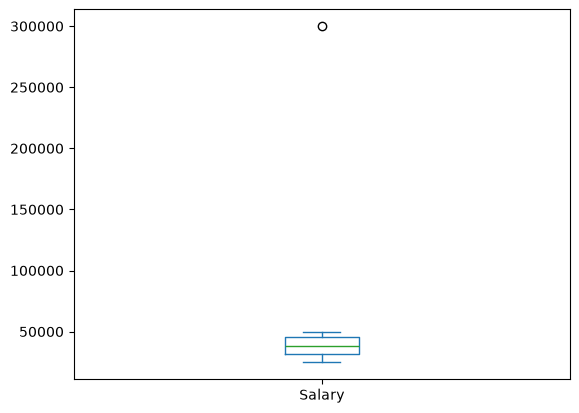

In [5]:
df['Salary'].plot(kind = 'box')

In [11]:
#Z score method
from scipy.stats import zscore

df["z_score"] = zscore(df["Salary"])

outliers = df[
    df["z_score"].abs() > 3
]

# we should not use z score mmethod here because the data is very much skewed here we should use isolation tree or IQR

In [12]:
outliers

,Employee,Age,Salary,z_score,outlier
11,L,80,300000,3.298696,-1


In [13]:
# Isolation forest

from sklearn.ensemble import IsolationForest

model = IsolationForest(
    contamination=0.05,
    random_state=42
)

model.fit(df[["Salary"]])

df["outlier"] = model.predict(
    df[["Salary"]]
)

In [14]:
df['outlier']
# -1 is outlier

0     1
1     1
2     1
3     1
4     1
5     1
6     1
7     1
8     1
9     1
10    1
11   -1
Name: outlier, dtype: int64

In [15]:
df

,Employee,Age,Salary,z_score,outlier
0,A,22,25000,-0.470590,1
1,B,24,28000,-0.429470,1
2,C,25,30000,-0.402057,1
3,D,26,32000,-0.374644,1
4,E,27,35000,-0.333525,1
5,F,28,37000,-0.306112,1
6,G,29,40000,-0.264992,1
7,H,30,42000,-0.237579,1
8,I,31,45000,-0.196460,1
9,J,32,48000,-0.155340,1
